get example aorc subhourly:

python forcing/aorc/aorc_extract_hourly.py     --center 2021-10-09T13:37:30 --window 5d     --timestep 15min --output-format netcdf     --index data/weighted_index_dict.pkl     --catchment-ids 'cat-269654' 'cat-269659' 'cat-271137' 'cat-271170' 'cat-271179' 'cat-271173' 'cat-271227' 'cat-271244' 'cat-270972' 'cat-270974' 'cat-270958' 'cat-270816' 'cat-270836' 'cat-270555' 'cat-270562' 'cat-270565' 'cat-271136' 'cat-271164' 'cat-271139' 'cat-271175' 'cat-271243' 'cat-270971' 'cat-270980' 'cat-270966' 'cat-270819' 'cat-270826' --upstream     --output-dir data/

In [39]:
import pandas as pd
import datetime as dt

events_path = '/Users/leoglonz/Desktop/noaa/flash-preprocess/data/huc8_03020201_events_and_gages.csv'

events = pd.read_csv(events_path)
print(events.head())

t_start, t_end = dt.datetime.strptime(events.iloc[0]['begin'], '%Y-%m-%d %H:%M:%S'), dt.datetime.strptime(events.iloc[0]['end'], '%Y-%m-%d %H:%M:%S')
print(f"\nEvent start: {t_start}, Event end: {t_end}")

t_mid = t_start + (t_end - t_start) / 2
print(f"Event midpoint: {t_mid}")

unique_gage_cats = events['gage_divide_id'].unique()
print(f"Unique gage categories: {unique_gage_cats}")
len(unique_gage_cats)

                source  storm_index  cluster_id  n_reports  \
0  event_storm_in_huc8       1355.0      4188.0        1.0   
1  event_storm_in_huc8       1356.0      4189.0        1.0   
2  event_storm_in_huc8       1385.0      4206.0        1.0   
3  event_storm_in_huc8       1494.0      4662.0        1.0   
4  event_storm_in_huc8       1688.0      4595.0        1.0   

                 begin                  end  duration_hours  centroid_lat  \
0  2021-10-09 13:00:00  2021-10-09 14:15:00            1.25       35.6006   
1  2021-10-09 08:06:00  2021-10-09 12:30:00            4.40       35.9016   
2  2021-10-09 09:28:00  2021-10-09 12:30:00            3.03       35.7309   
3  2021-10-09 10:25:00  2021-10-09 12:30:00            2.08       35.8410   
4  2021-10-09 06:30:00  2021-10-09 12:30:00            6.00       35.7714   

   centroid_lon  footprint_radius_km  ...  gage_snap_dist_m   gage_lat  \
0      -78.1463                 0.34  ...         12.503484  35.511389   
1      -78.7639 

19

In [66]:
# corrected csv:

corrected_events_path = '/Users/leoglonz/Desktop/noaa/flash-preprocess/data/huc8_03020201_events_and_gages_fixed.csv'

events_fixed = pd.read_csv(corrected_events_path)
print(events_fixed['found_divide_id'].unique())

[nan 'cat-269654' 'cat-269659' 'cat-271137' 'cat-271170' 'cat-271179'
 'cat-271173' 'cat-271227' 'cat-271244' 'cat-270972' 'cat-270974'
 'cat-270958' 'cat-270816' 'cat-270836' 'cat-270555' 'cat-270562'
 'cat-270565' 'cat-271136' 'cat-271164' 'cat-271139' 'cat-271175'
 'cat-271243' 'cat-270971' 'cat-270980' 'cat-270966' 'cat-270819'
 'cat-270826']


In [65]:
events_fixed['gage_divide_id']

0      cat-270565
1      cat-270971
2      cat-270819
3      cat-270972
4      cat-270958
          ...    
120           NaN
121           NaN
122           NaN
123           NaN
124           NaN
Name: gage_divide_id, Length: 125, dtype: object

In [45]:
events

,source,storm_index,cluster_id,n_reports,begin,end,duration_hours,centroid_lat,centroid_lon,footprint_radius_km,...,gage_snap_dist_m,gage_lat,gage_lon,centroid_to_gage_dist_km,centroid_in_huc8,gage_in_huc8,STAID,STATID,LAT_GAGE,LNG_GAGE
0,event_storm_in_huc8,1355.0,4188.0,1.0,2021-10-09 13:00:00,2021-10-09 14:15:00,1.25,35.6006,-78.1463,0.34,...,12.503484,35.511389,-78.160278,10.065260,True,True,NaN,NaN,NaN,NaN
1,event_storm_in_huc8,1356.0,4189.0,1.0,2021-10-09 08:06:00,2021-10-09 12:30:00,4.40,35.9016,-78.7639,0.10,...,24.524980,35.845278,-78.724444,7.227646,True,True,NaN,NaN,NaN,NaN
2,event_storm_in_huc8,1385.0,4206.0,1.0,2021-10-09 09:28:00,2021-10-09 12:30:00,3.03,35.7309,-78.7440,0.37,...,39.153079,35.693611,-78.692222,6.244170,True,True,NaN,NaN,NaN,NaN
3,event_storm_in_huc8,1494.0,4662.0,1.0,2021-10-09 10:25:00,2021-10-09 12:30:00,2.08,35.8410,-78.6803,0.11,...,24.697415,35.838056,-78.674167,0.640427,True,True,NaN,NaN,NaN,NaN
4,event_storm_in_huc8,1688.0,4595.0,1.0,2021-10-09 06:30:00,2021-10-09 12:30:00,6.00,35.7714,-78.7303,0.24,...,7.954088,35.758333,-78.583056,13.276285,True,True,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,new_gage_in_huc8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,208726005.0,208726005.0,35.845278,-78.724444
121,new_gage_in_huc8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,208732885.0,208732885.0,35.816944,-78.593056
122,new_gage_in_huc8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,208735012.0,208735012.0,35.780000,-78.666389
123,new_gage_in_huc8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,208758850.0,208758850.0,35.693611,-78.692222


In [21]:
events.iloc[[0]].to_csv('/Users/leoglonz/Desktop/noaa/flash-preprocess/data/huc8_event1.csv', index=True)

## Check AORC 15min forcing data

In [67]:
import xarray as xr

path = '/Users/leoglonz/Desktop/noaa/flash-preprocess/data/forcing.nc'

xr = xr.open_dataset(path)
print("data size: {:.2f} MB".format(xr.nbytes / (1024**2)))

xr

data size: 5.15 MB


<xarray.Dataset> Size: 5MB
Dimensions:              (time: 480, catchment: 350)
Coordinates:
  * time                 (time) datetime64[ns] 4kB 2021-10-07T01:45:00 ... 20...
  * catchment            (catchment) <U10 14kB 'cat-269651' ... 'cat-271254'
    latitude             (catchment) float32 1kB ...
    longitude            (catchment) float32 1kB ...
Data variables:
    APCP_surface         (catchment, time) float32 672kB ...
    DSWRF_surface        (catchment, time) float32 672kB ...
    TMP_2maboveground    (catchment, time) float32 672kB ...
    DLWRF_surface        (catchment, time) float32 672kB ...
    PRES_surface         (catchment, time) float32 672kB ...
    SPFH_2maboveground   (catchment, time) float32 672kB ...
    UGRD_10maboveground  (catchment, time) float32 672kB ...
    VGRD_10maboveground  (catchment, time) float32 672kB ...

# Hydrofabric

In [53]:
import geopandas as gpd


hf_path = '/Users/leoglonz/.ngiab/hydrofabric/v2.2/conus_nextgen.gpkg'

hf = gpd.read_file(hf_path, layer='divides')

In [54]:
hf.head()

,divide_id,toid,type,ds_id,areasqkm,vpuid,id,lengthkm,tot_drainage_areasqkm,has_flowline,geometry
0,cat-276,cnx-276,coastal,NaN,27.454477,01,None,NaN,NaN,False,"POLYGON ((2215875 2737364.998, 2215754.998 273..."
1,cat-275,cnx-275,coastal,NaN,25.207642,01,None,NaN,NaN,False,"POLYGON ((2229944.998 2745794.998, 2229825.002..."
2,cat-274,cnx-274,coastal,NaN,16.707601,01,None,NaN,NaN,False,"POLYGON ((2209485.004 2721074.997, 2209484.997..."
3,cat-273,cnx-273,coastal,NaN,32.822994,01,None,NaN,NaN,False,"POLYGON ((2242455 2784045.002, 2242485 2783834..."
4,cat-272,cnx-272,coastal,NaN,78.416994,01,None,NaN,NaN,False,"POLYGON ((2241225.003 2771205.002, 2241044.998..."


In [68]:
sel_cats = xr['catchment'].values

hf_sel = hf[hf['divide_id'].isin(sel_cats)]

<Axes: >

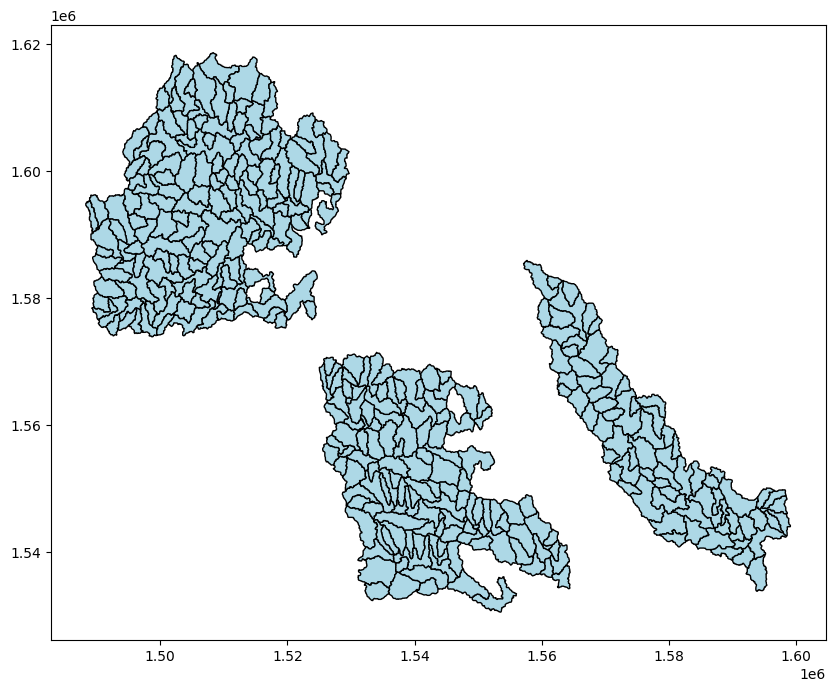

In [69]:
hf_sel.plot(figsize=(10, 10), color='lightblue', edgecolor='black')

Gage catchments missing from hf_sel: []


/var/folders/5l/9brv6cdn1b97f82knqyjcb4m0000gn/T/ipykernel_951/1244920625.py:54: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


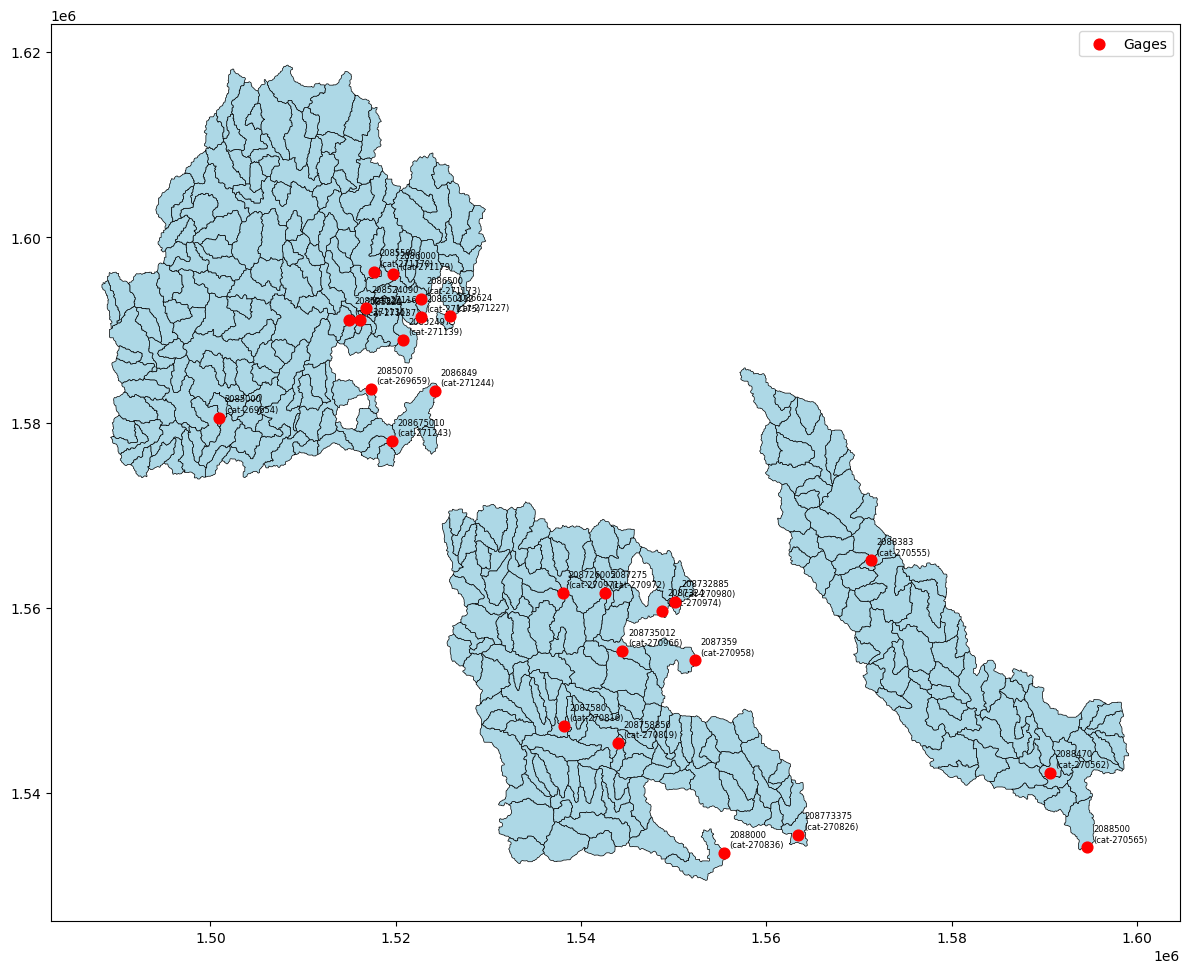

In [71]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

HYDROFABRIC = "/Users/leoglonz/.ngiab/hydrofabric/v2.2/conus_nextgen.gpkg"
events_path = '/Users/leoglonz/Desktop/noaa/flash-preprocess/data/huc8_03020201_events_and_gages.csv'

events = pd.read_csv(events_path)

gages = events.drop_duplicates("STAID").dropna(subset=["LAT_GAGE", "LNG_GAGE"])
gages_gdf = gpd.GeoDataFrame(
    gages,
    geometry=gpd.points_from_xy(gages["LNG_GAGE"], gages["LAT_GAGE"]),
    crs="EPSG:4326",
)

# Spatial join to find each gage's actual catchment
divides_bbox = gpd.read_file(
    HYDROFABRIC, layer="divides",
    bbox=tuple(gages_gdf.to_crs("EPSG:5070").total_bounds)  # tuple() required
)
joined = gpd.sjoin(
    gages_gdf.to_crs("EPSG:5070"),
    divides_bbox[["divide_id", "geometry"]],
    how="left", predicate="within"
)
gage_divide_ids = set(joined["divide_id"].dropna())

# Which of those are missing from hf_sel?
hf_ids = set(hf_sel["divide_id"])
missing_ids = gage_divide_ids - hf_ids
print(f"Gage catchments missing from hf_sel: {sorted(missing_ids)}")

# Load the missing polygons
missing_divides = divides_bbox[divides_bbox["divide_id"].isin(missing_ids)].to_crs(hf_sel.crs)

fig, ax = plt.subplots(figsize=(12, 12))
hf_sel.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.5, label="hf_sel catchments")
if len(missing_divides):
    missing_divides.plot(ax=ax, color="orange", edgecolor="black", linewidth=0.5, label="Missing catchments")

gages_proj = gages_gdf.to_crs(hf_sel.crs)
gages_proj.plot(ax=ax, color="red", markersize=60, zorder=5, label="Gages")

for _, row in joined.iterrows():
    geom = gages_proj.loc[row.name, "geometry"]
    ax.annotate(
        f"{int(row['STAID'])}\n({row.get('divide_id', '?')})",
        xy=(geom.x, geom.y),
        xytext=(4, 4), textcoords="offset points",
        fontsize=6,
    )

ax.legend()
plt.tight_layout()
plt.show()
